### Célula 1 — Imports e Carregamento dos Dados
Importamos todas as bibliotecas necessárias (scikit-learn, pandas, numpy, matplotlib, seaborn, joblib) e carregamos o dataset já pré-processado (`imdb_processed.parquet`). Exibimos a forma do DataFrame e a distribuição da variável alvo para confirmar que os dados estão prontos para modelagem.

In [2]:
import sys
sys.path.append('../')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import (classification_report, confusion_matrix, f1_score, accuracy_score, roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay, precision_recall_curve)
import scipy.sparse as sp

df = pd.read_parquet('../data/processed/imdb_processed.parquet')
print(f"Dataset carregado com sucesso!: {df.shape}")
print(f"Distribuição: {df['label'].value_counts().to_dict()}")

Dataset carregado com sucesso!: (49582, 11)
Distribuição: {1: 24884, 0: 24698}


### Célula 2 — Divisão Treino/Teste
Separamos os textos limpos, as features numéricas e o label. Usamos `train_test_split` com `stratify=y` para manter a proporção de classes (50/50) tanto no treino quanto no teste. Isso garante uma avaliação justa, especialmente em problemas balanceados.

In [3]:
X_text = df['review_clean']
y = df['label']

feat_cols = [c for c in df.columns if c.startswith('feat_')]
X_feats = df[feat_cols].values # Convertendo para array NumPy

X_text_train, X_text_test, X_feats_train, X_feats_test, y_train, y_test = \
    train_test_split(X_text, X_feats, y,
                     test_size=0.2,
                     random_state=42,
                     stratify=y)

print(f"Tamanho treino: {len(X_text_train):,}")
print(f"Tamanho teste:  {len(X_text_test):,}")
print(f"\nProporção no treino: {y_train.mean():.3f} (positivos)")
print(f"Proporção no teste:  {y_test.mean():.3f} (positivos)")
print("\nDivisão stratificada - proporções mantidas!")

Tamanho treino: 39,665
Tamanho teste:  9,917

Proporção no treino: 0.502 (positivos)
Proporção no teste:  0.502 (positivos)

Divisão stratificada - proporções mantidas!


### Célula 3 — Experimento 1: Vetorização TF-IDF Unigramas
Criamos uma matriz TF‑IDF considerando apenas palavras isoladas (unigramas). Limitamos a 20.000 features, removendo termos muito raros (`min_df=5`) e muito frequentes (`max_df=0.95`). Aplicamos `sublinear_tf` (1+log(tf)) para suavizar diferenças de frequência. Exibimos a esparsidade da matriz resultante.

In [4]:
print("Vetorizando com TF-IDF (1,1)...")

tfidf_1 = TfidfVectorizer(
    max_features=20000,    # top 20k termos mais frequentes
    ngram_range=(1, 1),    # apenas palavras individuais
    min_df=5,              # ignorar termos em menos de 5 documentos
    max_df=0.95,           # ignorar termos em mais de 95% dos documentos
    sublinear_tf=True,     # aplica log(1+tf) — melhora distribuição
)

X_train_1 = tfidf_1.fit_transform(X_text_train)
X_test_1 = tfidf_1.transform(X_text_test)

print(f"Shape da matriz treino: {X_train_1.shape}")
print(f"Sparsidade: {1 - X_train_1.nnz / (X_train_1.shape[0] * X_train_1.shape[1]):.4f}")
print(f"(~{(1 - X_train_1.nnz / (X_train_1.shape[0] * X_train_1.shape[1]))*100:.1f}% zeros)")

Vetorizando com TF-IDF (1,1)...
Shape da matriz treino: (39665, 20000)
Sparsidade: 0.9954
(~99.5% zeros)


### Célula 4 — Experimento 2: Vetorização TF-IDF com Bigramas
Expandimos a representação para incluir bigramas (`ngram_range=(1,2)`), capturando expressões como "not good" ou "highly recommended". Aumentamos o limite para 30.000 features e inspecionamos alguns bigramas presentes no vocabulário.

In [5]:
print("Vetorizando com TF-IDF (1,2)...")

tfidf_2 = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1, 2),    # unigramas + bigramas
    min_df=5,
    max_df=0.95,
    sublinear_tf=True,
)

X_train_2 = tfidf_2.fit_transform(X_text_train)
X_test_2 = tfidf_2.transform(X_text_test)

print(f"Shape: {X_train_2.shape}")
print(f"Exemplos de bigramas no vocabulário:")
vocab = tfidf_2.get_feature_names_out()
bigramas = [v for v in vocab if ' ' in v][:20]
print(bigramas)

Vetorizando com TF-IDF (1,2)...
Shape: (39665, 30000)
Exemplos de bigramas no vocabulário:
['aamir khan', 'abbott costello', 'ability make', 'able capture', 'able enjoy', 'able find', 'able get', 'able keep', 'able make', 'able relate', 'able see', 'able sit', 'able take', 'able understand', 'able watch', 'abraham lincoln', 'absolute must', 'absolute worst', 'absolutely amazing', 'absolutely awful']


### Célula 5 — Função de Avaliação Padronizada
Definimos `avaliar_modelo()`, que realiza validação cruzada estratificada (5-fold), treina no conjunto completo, avalia no teste e retorna um dicionário com F1-score (macro), acurácia, AUC-ROC e o gap de overfitting. Isso garante consistência e reprodutibilidade nas comparações.

In [6]:
def avaliar_modelo(nome, modelo, X_train, X_test, y_train, y_test, cv=5):
    
    # Cross-validation (treino)
    cv_obj = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)
    cv_scores = cross_val_score(modelo, X_train, y_train,
                                cv=cv_obj, scoring='f1_macro', n_jobs=-1)
    
    # Treino completo
    modelo.fit(X_train, y_train)
    
    # Avaliar no teste
    y_pred = modelo.predict(X_test)
    
    # Probabilidades
    if hasattr(modelo, 'predict_proba'):
        y_proba = modelo.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_proba)
    elif hasattr(modelo, 'decision_function'):
        y_proba = modelo.decision_function(X_test)
        auc = roc_auc_score(y_test, y_proba)
    else:
        y_proba = None
        auc = None
    
    # Métricas
    f1_train = cross_val_score(modelo, X_train, y_train,
                               cv=3, scoring='f1_macro', n_jobs=-1).mean()
    # (Re-treinar para obter métricas de treino completas)
    modelo.fit(X_train, y_train)
    f1_test = f1_score(y_test, y_pred, average='macro')
    acc_test = accuracy_score(y_test, y_pred)
    
    result = {
        'nome': nome,
        'f1_cv_mean': cv_scores.mean(),
        'f1_cv_std': cv_scores.std(),
        'f1_train': f1_train,
        'f1_test': f1_test,
        'acc_test': acc_test,
        'auc': auc,
        'overfit_gap': f1_train - f1_test,
        'modelo': modelo,
        'y_pred': y_pred,
        'y_proba': y_proba,
    }
    
    print(f"\n{'='*50}")
    print(f"{nome}")
    print(f"{'='*50}")
    print(f"  CV F1-Macro:  {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    print(f"  Teste F1:     {f1_test:.4f}")
    print(f"  Teste Acc:    {acc_test:.4f}")
    if auc:
        print(f"  AUC-ROC:      {auc:.4f}")
    print(f"  Overfit gap:  {result['overfit_gap']:.4f} {' CUIDADO' if result['overfit_gap'] > 0.05 else ' OK'}")
    
    return result

### Célula 6 — Treinamento e Avaliação de Quatro Modelos
Treinamos quatro classificadores: Naive Bayes Multinomial (baseline simples), Regressão Logística, LinearSVC e Random Forest. Para o Random Forest, reduzimos a dimensionalidade para 5.000 features (rápido). Todos são avaliados com a função anterior e armazenados em um dicionário `resultados`.

In [ ]:
X_tr, X_te = X_train_2, X_test_2

resultados = {}

# 1. Naive Bayes — baseline clássico para NLP
resultados['naive_bayes'] = avaliar_modelo(
    'Naive Bayes (MultinomialNB)',
    MultinomialNB(alpha=0.1),   # alpha = suavização de Laplace
    X_tr, X_te, y_train, y_test
)

# 2. Regressão Logística — geralmente o melhor para TF-IDF
resultados['logistic'] = avaliar_modelo(
    'Regressão Logística',
    LogisticRegression(
        C=1.0,            # inverso da regularização (maior = menos regularização)
        max_iter=1000,    # iterações máximas para convergência
        solver='lbfgs',   # algoritmo de otimização (bom para datasets médios)
        random_state=42
    ),
    X_tr, X_te, y_train, y_test
)

# 3. LinearSVC — muito eficiente em alta dimensionalidade
resultados['svc'] = avaliar_modelo(
    'LinearSVC',
    LinearSVC(
        C=1.0,
        max_iter=3000,
        random_state=42
    ),
    X_tr, X_te, y_train, y_test
)

# 4. Random Forest — mais lento, mas é comparativo útil
# Extremamente lento com TF-IDF de 30k features!
# Caso seja um problema, avalie reduzir n_features para este modelo
tfidf_rf = TfidfVectorizer(max_features=5000, ngram_range=(1,2), min_df=5, sublinear_tf=True)
X_tr_rf = tfidf_rf.fit_transform(X_text_train)
X_te_rf = tfidf_rf.transform(X_text_test)

resultados['random_forest'] = avaliar_modelo(
    'Random Forest (5k features)',
    RandomForestClassifier(
        n_estimators=200,
        max_depth=30,
        n_jobs=-1,         # usar todos os núcleos do processador 
        random_state=42
    ),
    X_tr_rf, X_te_rf, y_train, y_test
)


Naive Bayes (MultinomialNB)
  CV F1-Macro:  0.8800 ± 0.0042
  Teste F1:     0.8810
  Teste Acc:    0.8810
  AUC-ROC:      0.9500
  Overfit gap:  -0.0034  OK

Regressão Logística
  CV F1-Macro:  0.8991 ± 0.0021
  Teste F1:     0.9020
  Teste Acc:    0.9020
  AUC-ROC:      0.9661
  Overfit gap:  -0.0055  OK

LinearSVC
  CV F1-Macro:  0.8990 ± 0.0028
  Teste F1:     0.8994
  Teste Acc:    0.8994
  AUC-ROC:      0.9643
  Overfit gap:  -0.0036  OK

Random Forest (5k features)
  CV F1-Macro:  0.8431 ± 0.0034
  Teste F1:     0.8397
  Teste Acc:    0.8400
  AUC-ROC:      0.9261
  Overfit gap:  0.0014  OK


### Célula 7 — Comparação Visual dos Modelos
Criamos um DataFrame resumo com as principais métricas de cada modelo e geramos um gráfico de barras agrupadas (F1 CV, F1 Teste, AUC-ROC). O foco é identificar o modelo com melhor desempenho no conjunto de teste.

                     Modelo  F1 CV (mean)  F1 CV (±std)  F1 Teste  Acurácia      AUC  Overfit Gap
        Regressão Logística      0.899148      0.002071  0.901965  0.901986 0.966110    -0.005510
                  LinearSVC      0.899016      0.002799  0.899361  0.899365 0.964314    -0.003594
Naive Bayes (MultinomialNB)      0.879988      0.004162  0.880988  0.881012 0.950022    -0.003397
Random Forest (5k features)      0.843055      0.003404  0.839698  0.839972 0.926138     0.001415


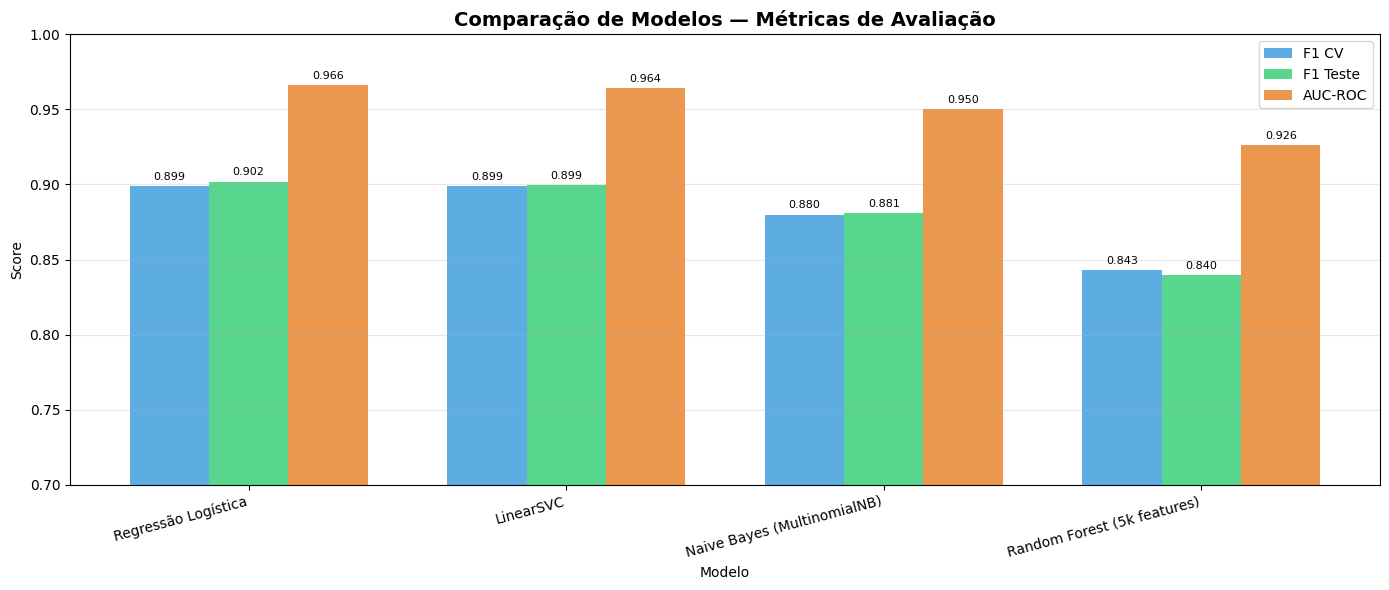

In [8]:
# Criar DataFrame de comparação
comp = pd.DataFrame([{
    'Modelo': v['nome'],
    'F1 CV (mean)': v['f1_cv_mean'],
    'F1 CV (±std)': v['f1_cv_std'],
    'F1 Teste': v['f1_test'],
    'Acurácia': v['acc_test'],
    'AUC': v['auc'] if v['auc'] else 0,
    'Overfit Gap': v['overfit_gap']
} for v in resultados.values()])

comp = comp.sort_values('F1 Teste', ascending=False)
print(comp.to_string(index=False))

# Gráfico de barras agrupadas
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(comp))
width = 0.25

bars1 = ax.bar(x - width, comp['F1 CV (mean)'], width, label='F1 CV', color='#3498db', alpha=0.8)
bars2 = ax.bar(x, comp['F1 Teste'], width, label='F1 Teste', color='#2ecc71', alpha=0.8)
bars3 = ax.bar(x + width, comp['AUC'], width, label='AUC-ROC', color='#e67e22', alpha=0.8)

ax.set_xlabel('Modelo')
ax.set_ylabel('Score')
ax.set_title('Comparação de Modelos — Métricas de Avaliação', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(comp['Modelo'], rotation=15, ha='right')
ax.legend()
ax.set_ylim(0.7, 1.0)  # zoom na área de destaque
ax.grid(axis='y', alpha=0.3)

# Valores nas barras
for bar in [*bars1, *bars2, *bars3]:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}',
                xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords='offset points',
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('../reports/figures/07_comparacao_modelos.png', dpi=150, bbox_inches='tight')
plt.show()

### Célula 8 — Métricas e Relatório de Classificação do Melhor Modelo, Matriz de Confusão, Curvas ROC e Precision-Recall 
Recuperamos o modelo campeão, exibimos suas métricas principais e geramos um `classification_report` completo (precisão, recall, f1 por classe). Essa análise detalhada ajuda a entender o comportamento em cada categoria (positivo/negativo). Além disso, plotamos a matriz de confusão em valores absolutos e normalizada (proporções). Interpretamos os falsos positivos e falsos negativos, calculando precisão e recall da classe positiva. Isso revela o tipo de erro mais comum, com isso, usando Curvas ROC e Precision-Recall verificamos, se o modelo fornecer probabilidades, traçamos a curva ROC (com AUC) e a curva Precision-Recall. Identificamos o threshold que maximiza o F1-score, útil se quisermos ajustar o ponto de decisão do modelo para favorecer precisão ou recall.

Melhor modelo: Regressão Logística
   F1-Macro: 0.9020
   AUC-ROC:  0.9661

              precision    recall  f1-score   support

    Negativo       0.91      0.89      0.90      4940
    Positivo       0.89      0.91      0.90      4977

    accuracy                           0.90      9917
   macro avg       0.90      0.90      0.90      9917
weighted avg       0.90      0.90      0.90      9917



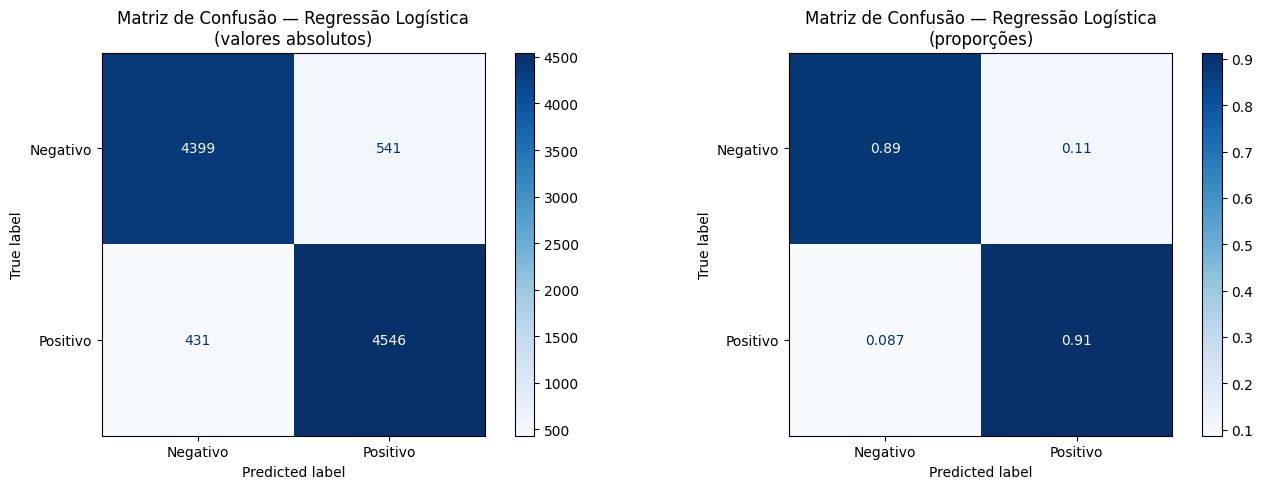


Interpretação:
  Verdadeiros Positivos:  4,546 (reviews positivas corretamente classificadas)
  Verdadeiros Negativos:  4,399 (reviews negativas corretamente classificadas)
  Falsos Positivos:       541 (negativas classificadas como positivas)
  Falsos Negativos:       431 (positivas classificadas como negativas)

Precisão Positivo: 0.894 — de cada 100 previstas como positivas, 89.4 são mesmo positivas
Recall Positivo:   0.913 — de cada 100 positivas reais, 91.3 foram detectadas


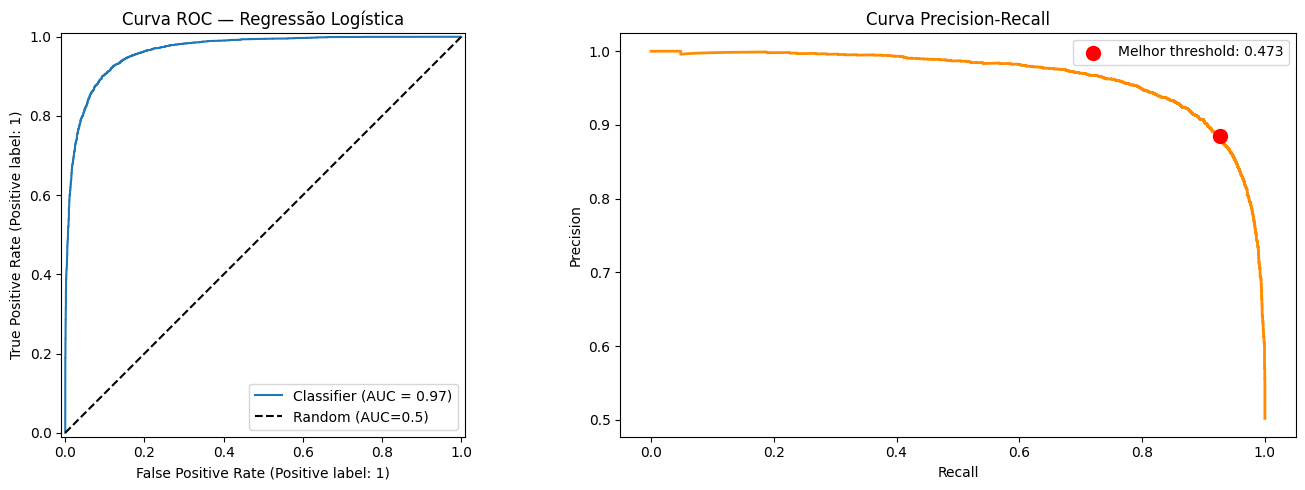


Melhor threshold para F1: 0.473
  Precision: 0.884
  Recall:    0.926
  F1:        0.905


In [9]:
melhor_nome = comp.iloc[0]['Modelo']
melhor_key = [k for k, v in resultados.items() if v['nome'] == melhor_nome][0]
melhor = resultados[melhor_key]

print(f"Melhor modelo: {melhor_nome}")
print(f"   F1-Macro: {melhor['f1_test']:.4f}")
print(f"   AUC-ROC:  {melhor['auc']:.4f}")

# Relatório completo de classificação
print("\n" + classification_report(
    y_test, melhor['y_pred'],
    target_names=['Negativo', 'Positivo']
))

# Matriz de confusão
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Absoluta
cm = confusion_matrix(y_test, melhor['y_pred'])
ConfusionMatrixDisplay(cm, display_labels=['Negativo', 'Positivo']).plot(ax=axes[0], cmap='Blues')
axes[0].set_title(f'Matriz de Confusão — {melhor_nome}\n(valores absolutos)')

# Normalizada
cm_norm = confusion_matrix(y_test, melhor['y_pred'], normalize='true')
ConfusionMatrixDisplay(cm_norm, display_labels=['Negativo', 'Positivo']).plot(ax=axes[1], cmap='Blues')
axes[1].set_title(f'Matriz de Confusão — {melhor_nome}\n(proporções)')

plt.tight_layout()
plt.savefig('../reports/figures/08_matriz_confusao.png', dpi=150, bbox_inches='tight')
plt.show()

# Interpretação
tn, fp, fn, tp = cm.ravel()
print(f"\nInterpretação:")
print(f"  Verdadeiros Positivos:  {tp:,} (reviews positivas corretamente classificadas)")
print(f"  Verdadeiros Negativos:  {tn:,} (reviews negativas corretamente classificadas)")
print(f"  Falsos Positivos:       {fp:,} (negativas classificadas como positivas)")
print(f"  Falsos Negativos:       {fn:,} (positivas classificadas como negativas)")
print(f"\nPrecisão Positivo: {tp/(tp+fp):.3f} — de cada 100 previstas como positivas, {tp/(tp+fp)*100:.1f} são mesmo positivas")
print(f"Recall Positivo:   {tp/(tp+fn):.3f} — de cada 100 positivas reais, {tp/(tp+fn)*100:.1f} foram detectadas")

if melhor['y_proba'] is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # ROC
    RocCurveDisplay.from_predictions(y_test, melhor['y_proba'], ax=axes[0])
    axes[0].plot([0,1],[0,1], 'k--', label='Random (AUC=0.5)')
    axes[0].set_title(f'Curva ROC — {melhor_nome}')
    axes[0].legend()
    
    # Precision-Recall
    precision, recall, thresholds = precision_recall_curve(y_test, melhor['y_proba'])
    f1_scores_curve = 2 * precision * recall / (precision + recall + 1e-8)
    best_thresh_idx = f1_scores_curve.argmax()
    
    axes[1].plot(recall, precision, color='darkorange', lw=2)
    axes[1].scatter(recall[best_thresh_idx], precision[best_thresh_idx],
                    color='red', s=100, zorder=5,
                    label=f'Melhor threshold: {thresholds[best_thresh_idx]:.3f}')
    axes[1].set_xlabel('Recall')
    axes[1].set_ylabel('Precision')
    axes[1].set_title('Curva Precision-Recall')
    axes[1].legend()
    
    plt.tight_layout()
    plt.savefig('../reports/figures/09_curvas_roc_pr.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\nMelhor threshold para F1: {thresholds[best_thresh_idx]:.3f}")
    print(f"  Precision: {precision[best_thresh_idx]:.3f}")
    print(f"  Recall:    {recall[best_thresh_idx]:.3f}")
    print(f"  F1:        {f1_scores_curve[best_thresh_idx]:.3f}")



### Célula 09 — Interpretabilidade: Palavras Mais Influentes
Para modelos lineares (Regressão Logística, LinearSVC), extraímos os coeficientes das features para revelar as palavras/bigramas mais associadas a sentimento positivo e negativo. Um gráfico de barras horizontais destaca os termos mais discriminativos.

TOP 20 PALAVRAS/BIGRAMAS → SENTIMENTO POSITIVO:
  great                     +7.887  ███████████████████████████████████████
  excellent                 +7.042  ███████████████████████████████████
  perfect                   +5.760  ████████████████████████████
  amazing                   +5.251  ██████████████████████████
  best                      +5.182  █████████████████████████
  wonderful                 +5.109  █████████████████████████
  loved                     +4.534  ██████████████████████
  one best                  +4.503  ██████████████████████
  brilliant                 +4.498  ██████████████████████
  favorite                  +4.363  █████████████████████
  today                     +4.110  ████████████████████
  love                      +4.106  ████████████████████
  enjoyed                   +4.092  ████████████████████
  superb                    +4.063  ████████████████████
  hilarious                 +4.057  ████████████████████
  fun                       +4.0

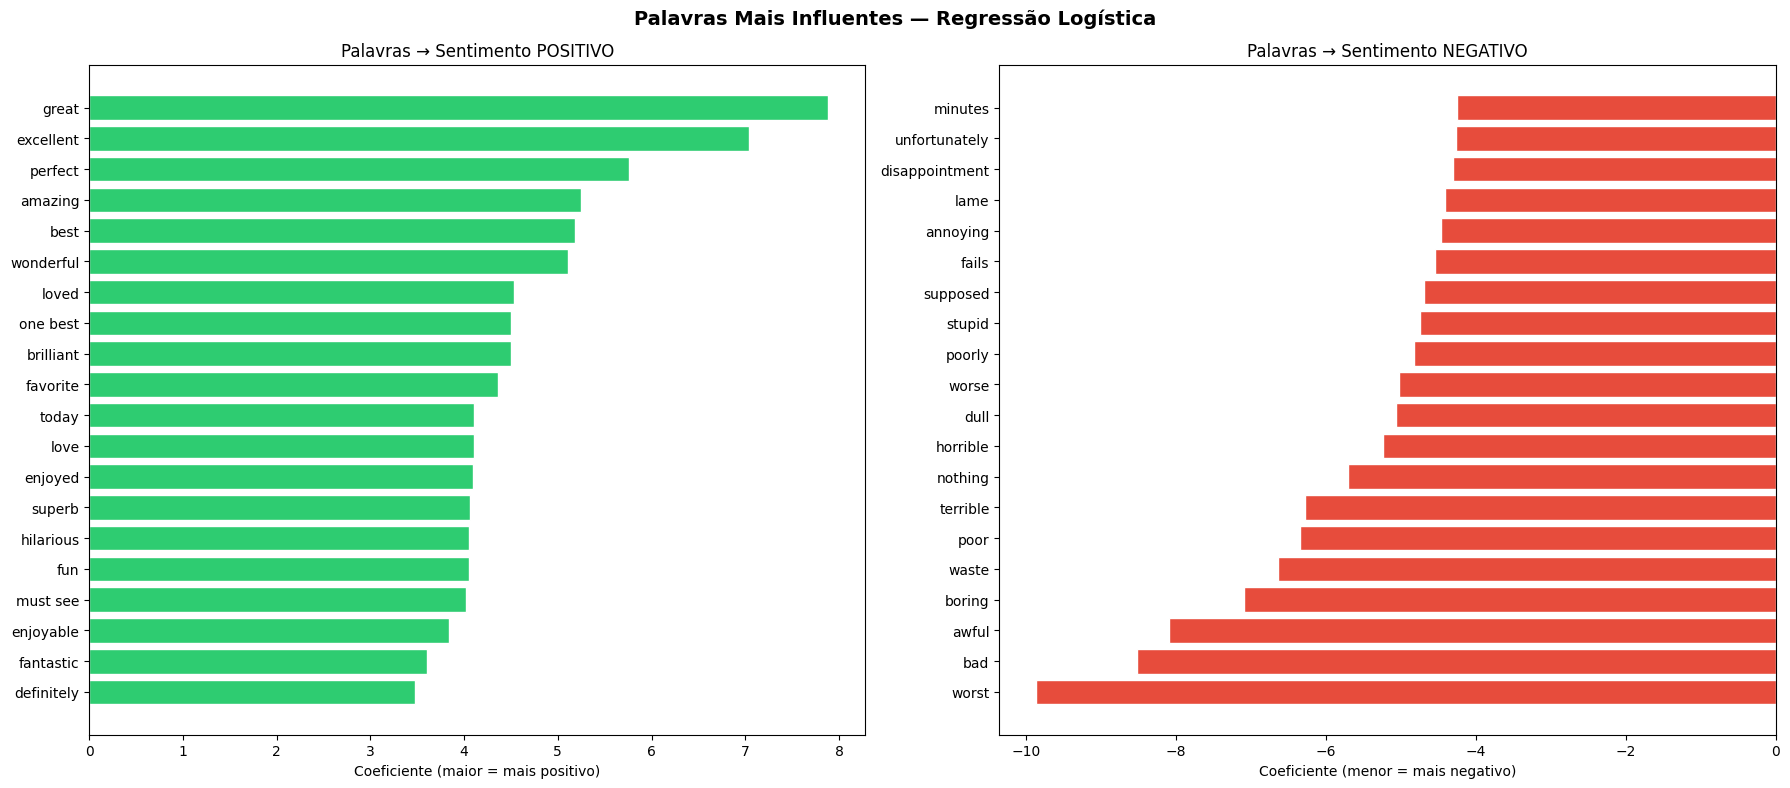

In [10]:
# Funciona para Regressão Logística e LinearSVC
modelo_final = melhor['modelo']
vetorizador = tfidf_2

if hasattr(modelo_final, 'coef_'):
    coeficientes = modelo_final.coef_[0] if len(modelo_final.coef_.shape) > 1 else modelo_final.coef_
    feature_names = vetorizador.get_feature_names_out()
    
    # Top 30 em cada direção
    n = 30
    top_pos_idx = coeficientes.argsort()[-n:][::-1]
    top_neg_idx = coeficientes.argsort()[:n]
    
    top_positivas = [(feature_names[i], coeficientes[i]) for i in top_pos_idx]
    top_negativas = [(feature_names[i], coeficientes[i]) for i in top_neg_idx]
    
    print("TOP 20 PALAVRAS/BIGRAMAS → SENTIMENTO POSITIVO:")
    for word, coef in top_positivas[:20]:
        bar = '█' * int(abs(coef) * 5)
        print(f"  {word:25s} {coef:+.3f}  {bar}")
    
    print("\nTOP 20 PALAVRAS/BIGRAMAS → SENTIMENTO NEGATIVO:")
    for word, coef in top_negativas[:20]:
        bar = '█' * int(abs(coef) * 5)
        print(f"  {word:25s} {coef:+.3f}  {bar}")
    
    # Gráfico
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    fig.suptitle(f'Palavras Mais Influentes — {melhor_nome}', fontsize=14, fontweight='bold')
    
    # Positivas
    words_pos = [w for w, _ in top_positivas[:20]]
    coefs_pos = [c for _, c in top_positivas[:20]]
    axes[0].barh(words_pos[::-1], coefs_pos[::-1], color='#2ecc71', edgecolor='white')
    axes[0].set_title('Palavras → Sentimento POSITIVO')
    axes[0].set_xlabel('Coeficiente (maior = mais positivo)')
    
    # Negativas
    words_neg = [w for w, _ in top_negativas[:20]]
    coefs_neg = [c for _, c in top_negativas[:20]]
    axes[1].barh(words_neg, coefs_neg, color='#e74c3c', edgecolor='white')
    axes[1].set_title('Palavras → Sentimento NEGATIVO')
    axes[1].set_xlabel('Coeficiente (menor = mais negativo)')
    
    plt.tight_layout()
    plt.savefig('../reports/figures/10_palavras_influentes.png', dpi=150, bbox_inches='tight')
    plt.show()

### Célula 10 — Análise de Erros do Modelo
Criamos um DataFrame com as predições, confiança e revisão original. Investigamos falsos positivos com alta certeza (possíveis casos de ironia/sarcasmo) e calculamos a acurácia por faixa de comprimento da review, identificando onde o modelo tem mais dificuldade.

In [11]:
df_test = pd.DataFrame({
    'review_clean': X_text_test.values,
    'review_original': df.loc[X_text_test.index, 'review'].values,
    'y_true': y_test.values,
    'y_pred': melhor['y_pred'],
    'correto': y_test.values == melhor['y_pred']
})

if melhor['y_proba'] is not None:
    df_test['confianca'] = melhor['y_proba']
    
    # Falsos positivos com ALTA confiança (casos difíceis)
    falsos_positivos = df_test[
        (df_test['y_true'] == 0) &
        (df_test['y_pred'] == 1) &
        (df_test['confianca'] > 0.8)
    ]
    
    print(f"Falsos Positivos com confiança > 0.8: {len(falsos_positivos)}")
    print("\nExemplos (reviews negativas classificadas como positivas com alta confiança):")
    print("ALERTA: Esses casos geralmente contêm ironia/sarcasmo!\n")
    
    for i, (_, row) in enumerate(falsos_positivos.head(3).iterrows()):
        print(f"[Caso {i+1}] Confiança de POSITIVO: {row['confianca']:.3f}")
        print(f"Review original: {row['review_original'][:300]}")
        print()

# Resumo de acertos por comprimento de review
df_test['n_words'] = df_test['review_clean'].apply(lambda x: len(x.split()))
df_test['n_words_bucket'] = pd.cut(df_test['n_words'], bins=[0, 50, 100, 200, 500, 10000],
                                    labels=['<50', '50-100', '100-200', '200-500', '>500'])

accuracy_by_length = df_test.groupby('n_words_bucket')['correto'].mean()
print("\nAcurácia por comprimento da review:")
print(accuracy_by_length.round(3))
print("\nReviews mais curtas geralmente são mais difíceis de classificar.")

Falsos Positivos com confiança > 0.8: 68

Exemplos (reviews negativas classificadas como positivas com alta confiança):
ALERTA: Esses casos geralmente contêm ironia/sarcasmo!

[Caso 1] Confiança de POSITIVO: 0.812
Review original: Richard Dix is a big, not very nice industrialist, who has nearly worked himself to death. If he takes the vacation his doctors suggest for him, can he find happiness for the last months of his life? Well, he'll likely be better off if he disregards the VOICE OF THE WHISTLER.<br /><br />This William

[Caso 2] Confiança de POSITIVO: 0.897
Review original: I saw this movie in 1956 and again on Cable a few days ago. The movie hasn't improved with age. Quite the opposite. It's a true spaghetti epic.<br /><br />The Trojans are heroic and likable; the Greeks are nasty, petty and sneaky.<br /><br />So what if Paris ran off with the King's wife? Hey...love 

[Caso 3] Confiança de POSITIVO: 0.852
Review original: This appears to be two movies spliced into one. In the 

### Célula 11 — Otimização de Hiperparâmetros (Regressão Logística)
Realizamos uma busca aleatória (`RandomizedSearchCV`) para ajustar o parâmetro de regularização `C`, o solver e o número de iterações. Avaliamos 20 combinações com validação cruzada e medimos a melhora no F1-score do teste.

In [12]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform

# Definir grade de parâmetros
param_distributions = {
    'C': loguniform(0.001, 100),        # busca em espaço log-uniforme
    'solver': ['lbfgs', 'liblinear', 'saga'],
    'max_iter': [500, 1000, 2000]
}

print("Iniciando busca de hiperparâmetros (pode demorar alguns minutos)...")

search = RandomizedSearchCV(
    LogisticRegression(random_state=42),
    param_distributions,
    n_iter=20,              # 20 combinações aleatórias
    cv=5,                   # 5-fold CV
    scoring='f1_macro',
    n_jobs=-1,              # paralelizar
    random_state=42,
    verbose=1
)

search.fit(X_train_2, y_train)

print(f"\nBusca concluída!")
print(f"Melhores parâmetros: {search.best_params_}")
print(f"Melhor F1 CV: {search.best_score_:.4f}")

# Avaliação do teste
y_pred_opt = search.predict(X_test_2)
f1_opt = f1_score(y_test, y_pred_opt, average='macro')
print(f"F1 no teste: {f1_opt:.4f}")

# Comparando com modelo padrão
print(f"\nMelhoria: {f1_opt - melhor['f1_test']:+.4f}")

Iniciando busca de hiperparâmetros (pode demorar alguns minutos)...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Busca concluída!
Melhores parâmetros: {'C': np.float64(4.5705630998014515), 'max_iter': 500, 'solver': 'lbfgs'}
Melhor F1 CV: 0.9020
F1 no teste: 0.9066

Melhoria: +0.0047


### Célula 12 — Salvamento do Modelo Final
Serializamos o melhor estimador e o vetorizador TF‑IDF com `joblib`. Também salvamos um JSON com as métricas finais (F1, acurácia, AUC, tamanho do vocabulário, etc.) para documentar a performance e permitir a reprodução futura.

In [13]:
modelo_final = search.best_estimator_

# Serializar modelo + vetorizador juntos
import joblib

joblib.dump(tfidf_2, '../models/tfidf_vectorizer.pkl')
joblib.dump(modelo_final, '../models/sentiment_model.pkl')

print("Vetorizador salvo: models/tfidf_vectorizer.pkl")
print("Modelo salvo:      models/sentiment_model.pkl")

# Salvar métricas finais
import json
metricas_finais = {
    'model_type': type(modelo_final).__name__,
    'best_params': search.best_params_,
    'f1_macro_cv': float(search.best_score_),
    'f1_macro_test': float(f1_opt),
    'accuracy_test': float(accuracy_score(y_test, y_pred_opt)),
    'auc_roc': float(roc_auc_score(y_test, search.predict_proba(X_test_2)[:, 1])),
    'n_train': len(X_text_train),
    'n_test': len(X_text_test),
    'vocab_size': len(tfidf_2.get_feature_names_out()),
}

with open('../models/metricas_finais.json', 'w') as f:
    json.dump(metricas_finais, f, indent=2)

print("\nMétricas finais:")
print(json.dumps(metricas_finais, indent=2))

Vetorizador salvo: models/tfidf_vectorizer.pkl
Modelo salvo:      models/sentiment_model.pkl

Métricas finais:
{
  "model_type": "LogisticRegression",
  "best_params": {
    "C": 4.5705630998014515,
    "max_iter": 500,
    "solver": "lbfgs"
  },
  "f1_macro_cv": 0.9020143968747169,
  "f1_macro_test": 0.9066178004891634,
  "accuracy_test": 0.9066249873953817,
  "auc_roc": 0.9675384501500425,
  "n_train": 39665,
  "n_test": 9917,
  "vocab_size": 30000
}


### Célula 13 — Teste Manual do Modelo
Criamos uma função `prever_sentimento()` que recebe um texto bruto, aplica a limpeza, vetoriza e exibe a predição com probabilidades. Testamos com frases representativas (incluindo negações e casos ambíguos) para validar qualitativamente o comportamento do modelo.

In [14]:
def prever_sentimento(texto, vetorizador, modelo, limiar=0.5):
    import sys
    sys.path.append('../')
    from src.text_utils import clean_text_basic
    
    texto_limpo = clean_text_basic(texto)
    vetor = vetorizador.transform([texto_limpo])
    proba = modelo.predict_proba(vetor)[0]
    
    sentimento = 'POSITIVO' if proba[1] >= limiar else 'NEGATIVO'
    confianca = max(proba) * 100
    
    print(f"Texto: '{texto[:80]}...' " if len(texto) > 80 else f"Texto: '{texto}'")
    print(f"Limpo: '{texto_limpo[:80]}...' " if len(texto_limpo) > 80 else f"Limpo: '{texto_limpo}'")
    print(f"Resultado: {sentimento} (confiança: {confianca:.1f}%)")
    print(f"  P(Positivo): {proba[1]:.3f}")
    print(f"  P(Negativo): {proba[0]:.3f}")
    print()

# Testes
testes = [
    "This movie was absolutely fantastic! The acting was superb and the story kept me on edge.",
    "Terrible film. Complete waste of two hours. The plot makes no sense whatsoever.",
    "It was okay, nothing special. Some parts were good but overall pretty average.",
    "The worst movie I have ever seen. Pure garbage.",
    "Not bad! I was surprised by how much I enjoyed this one.",  
    "I can't believe they made this masterpiece. Stunning visuals and incredible soundtrack.",
]

print("="*60)
print("TESTES MANUAIS DO MODELO")
print("="*60 + "\n")

for texto in testes:
    prever_sentimento(texto, tfidf_2, modelo_final)

TESTES MANUAIS DO MODELO

Texto: 'This movie was absolutely fantastic! The acting was superb and the story kept me...' 
Limpo: 'movie absolutely fantastic acting superb story kept edge'
Resultado: POSITIVO (confiança: 98.6%)
  P(Positivo): 0.986
  P(Negativo): 0.014

Texto: 'Terrible film. Complete waste of two hours. The plot makes no sense whatsoever.'
Limpo: 'terrible film complete waste two hours plot makes sense whatsoever'
Resultado: NEGATIVO (confiança: 99.9%)
  P(Positivo): 0.001
  P(Negativo): 0.999

Texto: 'It was okay, nothing special. Some parts were good but overall pretty average.'
Limpo: 'okay nothing special parts good overall pretty average'
Resultado: NEGATIVO (confiança: 84.6%)
  P(Positivo): 0.154
  P(Negativo): 0.846

Texto: 'The worst movie I have ever seen. Pure garbage.'
Limpo: 'worst movie ever seen pure garbage'
Resultado: NEGATIVO (confiança: 99.7%)
  P(Positivo): 0.003
  P(Negativo): 0.997

Texto: 'Not bad! I was surprised by how much I enjoyed this one.'
Li